# Checking python version and libs for compatiablity


In [ ]:
import sys
import cv2
import mediapipe as mp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Python version: {sys.version}")
print(f"OpenCV version: {cv2.__version__}")
print(f"MediaPipe version: {mp.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")

mp_pose = mp.solutions.pose
print("solutions API works!")

Analyzing one frame using MediaPipe

In [ ]:
# Start with the forehand video
video_path = "training_vid/forehand.mp4"

cap = cv2.VideoCapture(video_path)

print(f"Video opened: {cap.isOpened()}")
print(f"Total frames: {int(cap.get(cv2.CAP_PROP_FRAME_COUNT))}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")
print(f"Width: {int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))}")
print(f"Height: {int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))}")

cap.release()

# Function to extract landmarks in every frame of a vid

In [ ]:

def video_landmarks(video_path: str, output_csv: str):
    all_landmarks = []

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = 0

    with mp_pose.Pose() as pose:
        while cap.isOpened():   #if vid was opened successfully
            success, frame = cap.read()     #read() returns 2 vals: bool if frame can be opened and the frame data
            
            if not success: #runs out of frames to process
                break
            
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) #converts color from BGR to RGB because mediapipe needs this format
            results = pose.process(frame_rgb)   # processes the frame for 33 landmarks
            
            if results.pose_landmarks:
                row = {"frame": frame_count, "timestamp": frame_count/fps} #adds these 2 cols into each row
                
                for landmark in mp_pose.PoseLandmark: #records the x,y,z pos and visiility of each landmark
                    lm = results.pose_landmarks.landmark[landmark]
                    
                    #adds 4 coords of each landmark in row
                    row[f"{landmark.name}_x"] = lm.x
                    row[f"{landmark.name}_y"] = lm.y
                    row[f"{landmark.name}_z"] = lm.z
                    row[f"{landmark.name}_vis"] = lm.visibility
                
                all_landmarks.append(row)
                
            frame_count += 1
            
            if frame_count % 100 == 0:
                print(f"Processed {frame_count} frames")

    cap.release()
    df = pd.DataFrame(all_landmarks) 
    df.to_csv(output_csv, index= False)
    print(f"Done! Processed {frame_count} total frames")
    print(f"Frames with landmarks: {len(all_landmarks)}")
    print(f"Saved to {output_csv}")
    return df
                

# Capturing frame data from vids


In [ ]:
df_forehand = video_landmarks("training_vid/forehand_train.mp4", "stroke_csv/forehand_landmarks.csv")
df_backhand = video_landmarks("training_vid/backhand_train.mp4", "stroke_csv/backhand_landmarks.csv")
df_match = video_landmarks("training_vid/match_train.mp4", "stroke_csv/match_landmarks.csv")

### Function to plot wrist positions

In [ ]:
def plot_wrist(df, title):
    plt.scatter(df["RIGHT_WRIST_x"], df["RIGHT_WRIST_y"], alpha = .1)
    plt.title(title)
    plt.xlabel("X coord")
    plt.ylabel("Y coord")
    plt.gca().invert_yaxis() # inverts y axis because 0 is at top in image coords
    plt.show()

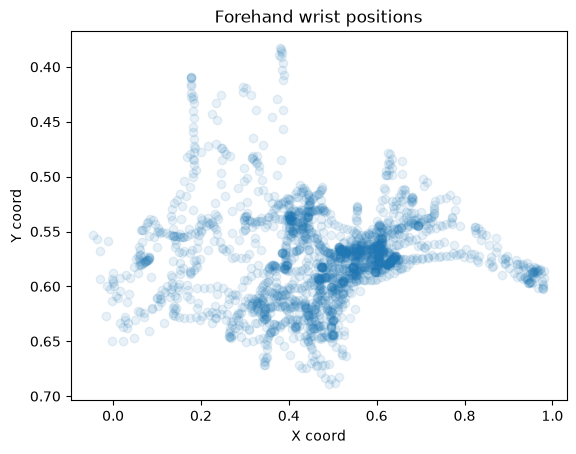

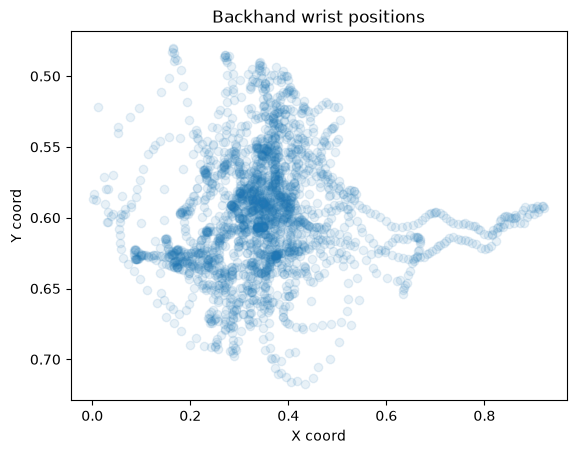

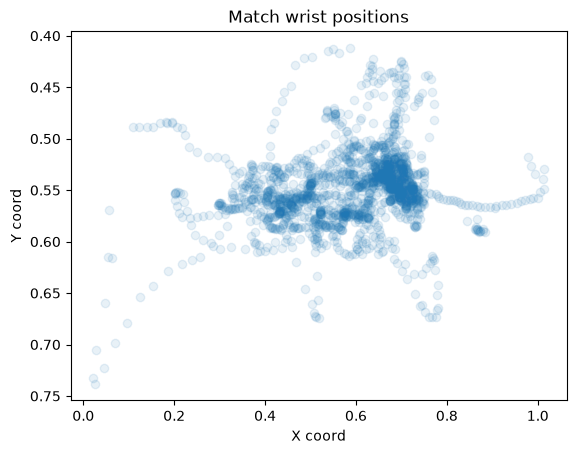

In [30]:
plot_wrist(df_forehand, "Forehand wrist positions")
plot_wrist(df_backhand, "Backhand wrist positions")
plot_wrist(df_match, "Match wrist positions")

In [29]:
df_forehand.shape
df_backhand.shape
df_match.shape

(1891, 134)